# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdrayan001/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
# ---------------------------------------------------------
# 1. Question
# ---------------------------------------------------------

research_question = (
    "Which pages should be reviewed first for refresh, expansion, "
    "protection, pruning, or monitoring using observable search, "
    "engagement, freshness, and content signals?"
)

decision_supported = (
    "Prioritize limited SEO/content review capacity by ranking pages "
    "for human review."
)

actor = "SEO/content strategist or editor"

action = (
    "Review the ranked page, inspect the reason code, and decide whether "
    "to refresh, review CTR, protect, monitor, or assign lower priority."
)

cost_of_wrong_call = (
    "A false positive can waste review capacity, while a false negative "
    "can cause a valuable opportunity or genuine weakness to be missed."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nPrimary user:")
print(actor)

print("\nAction:")
print(action)

print("\nCost of a wrong call:")
print(cost_of_wrong_call)

assert research_question
assert decision_supported
assert actor
assert action
assert cost_of_wrong_call

print("\nQuestion section check passed.")

Research question:
Which pages should be reviewed first for refresh, expansion, protection, pruning, or monitoring using observable search, engagement, freshness, and content signals?

Decision supported:
Prioritize limited SEO/content review capacity by ranking pages for human review.

Primary user:
SEO/content strategist or editor

Action:
Review the ranked page, inspect the reason code, and decide whether to refresh, review CTR, protect, monitor, or assign lower priority.

Cost of a wrong call:
A false positive can waste review capacity, while a false negative can cause a valuable opportunity or genuine weakness to be missed.

Question section check passed.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
# ---------------------------------------------------------
# 2. Data
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd

# Find the starter dataset from the notebook location
candidate_paths = [
    Path("../../data/raw/content_refresh_anonymized.csv"),
    Path("data/raw/content_refresh_anonymized.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

assert data_path is not None, (
    "Could not find content_refresh_anonymized.csv. "
    "Check that the notebook is inside work/notebooks/."
)

df_capstone = pd.read_csv(data_path)

print("Dataset:", data_path)
print("Rows:", len(df_capstone))
print("Columns:", len(df_capstone.columns))

print("\nExpected starter dataset:")
print("Rows: 30,000")
print("Columns: 44")

print("\nUnique clients:", df_capstone["client_id"].nunique())
print("Unique content items:", df_capstone["content_id"].nunique())

print("\nMetric window:")
print("Trailing 90-day search and engagement metrics")

print("\nDate field available:")
print("content_created_date")

# ---------------------------------------------------------
# Public-safety / exclusion checks
# ---------------------------------------------------------

excluded_fields = [
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id",
    "needs_ctr_fix",
    "is_quick_win",
    "needs_engagement_fix",
    "ai_opportunity",
    "is_underperformer",
    "is_initial_refresh_candidate",
    "health_score",
]

present_excluded = [
    col for col in excluded_fields
    if col in df_capstone.columns
]

print("\nExcluded from modeling:")
for col in present_excluded:
    print("-", col)

# Check for obvious private/public-unsafe fields
unsafe_name_patterns = [
    "domain",
    "url",
    "query",
    "keyword",
    "client_name",
]

unsafe_columns = [
    col for col in df_capstone.columns
    if any(pattern in col.lower() for pattern in unsafe_name_patterns)
]

print("\nPotentially sensitive/public-unsafe columns found:")
print(unsafe_columns if unsafe_columns else "None")

# ---------------------------------------------------------
# Data quality checks
# ---------------------------------------------------------

assert len(df_capstone) == 30000
assert df_capstone["client_id"].nunique() == 32
assert df_capstone["content_id"].nunique() == 30000

print("\nData section check passed.")

Dataset: ..\..\data\raw\content_refresh_anonymized.csv
Rows: 30000
Columns: 44

Expected starter dataset:
Rows: 30,000
Columns: 44

Unique clients: 32
Unique content items: 30000

Metric window:
Trailing 90-day search and engagement metrics

Date field available:
content_created_date

Excluded from modeling:
- trend_direction
- trend_pct
- content_id
- client_id

Potentially sensitive/public-unsafe columns found:
None

Data section check passed.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [5]:
# ---------------------------------------------------------
# 3. Methodology
# ---------------------------------------------------------

import numpy as np
from sklearn.model_selection import GroupShuffleSplit


# ---------------------------------------------------------
# Label definition
# ---------------------------------------------------------

label_col = "trend_direction"
target_value = "down"

# Current decline proxy:
# 1 = page is currently marked as "down"
# 0 = all other trend directions
df_capstone["decline_proxy"] = (
    df_capstone[label_col] == target_value
).astype(int)

print("Target / decline proxy:")
print("1 = trend_direction == 'down'")
print("0 = all other trend directions")

print("\nTarget distribution:")
print(
    df_capstone["decline_proxy"]
    .value_counts()
    .sort_index()
)

print("\nTarget rate:")
print(round(df_capstone["decline_proxy"].mean(), 3))


# ---------------------------------------------------------
# Final model features
# ---------------------------------------------------------

feature_cols = [
    "impressions_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "avg_position_missing",
]

# Keep the original dataframe unchanged.
# Create a separate dataframe for model preparation.
model_df = df_capstone.copy()

# In the FlyRank data contract, avg_position = 0 means
# no position data. We therefore create an explicit
# missingness flag and treat 0 as missing for modeling.
model_df["avg_position_missing"] = (
    model_df["avg_position"] == 0
).astype(int)

model_df["avg_position"] = model_df["avg_position"].replace(
    0, np.nan
)

X = model_df[feature_cols].copy()
y = model_df["decline_proxy"].copy()
groups = model_df["client_id"].copy()

print("\nFinal model features:")
for feature in feature_cols:
    print("-", feature)


# ---------------------------------------------------------
# Leakage / forbidden-field audit
# ---------------------------------------------------------

forbidden_fields = [
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id",
    "needs_ctr_fix",
    "is_quick_win",
    "needs_engagement_fix",
    "ai_opportunity",
    "is_underperformer",
    "is_initial_refresh_candidate",
    "health_score",
]

used_forbidden = [
    col for col in forbidden_fields
    if col in feature_cols
]

print("\nForbidden fields used in model:")
print(used_forbidden)

assert used_forbidden == []


# ---------------------------------------------------------
# Grouped validation design
# ---------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("\nValidation design:")
print("Split type: Client-grouped holdout")
print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

print("\nTrain decline rate:")
print(round(y_train.mean(), 3))

print("Test decline rate:")
print(round(y_test.mean(), 3))

assert len(train_clients & test_clients) == 0


# ---------------------------------------------------------
# Baseline definition
# ---------------------------------------------------------

baseline_description = (
    "Week-4 rule-based score using CTR gap by position bucket, "
    "staleness, and search visibility."
)

print("\nBaseline:")
print(baseline_description)


# ---------------------------------------------------------
# Model definition
# ---------------------------------------------------------

model_description = (
    "Logistic Regression and Random Forest using the seven final "
    "features, with balanced class weights."
)

print("\nModels:")
print(model_description)


# ---------------------------------------------------------
# Evaluation metric
# ---------------------------------------------------------

metric = (
    "Precision@K, with Precision@20 and Precision@50 reported."
)

print("\nPrimary evaluation metric:")
print(metric)


# ---------------------------------------------------------
# Methodology assumptions
# ---------------------------------------------------------

print("\nKey assumptions:")
print(
    "- trend_direction == 'down' is used only as a current "
    "decline proxy."
)
print(
    "- avg_position = 0 is treated as missing position data."
)
print(
    "- client-grouped validation is used to test performance "
    "on unseen clients."
)
print(
    "- IDs and target-derived/product-derived fields are not "
    "used as model features."
)
print(
    "- Results are decision-support evidence, not causal proof."
)


# ---------------------------------------------------------
# Final checks
# ---------------------------------------------------------

assert len(feature_cols) == 7
assert len(train_idx) + len(test_idx) == len(df_capstone)
assert len(train_clients & test_clients) == 0
assert used_forbidden == []

print("\nMethodology section check passed.")

Target / decline proxy:
1 = trend_direction == 'down'
0 = all other trend directions

Target distribution:
decline_proxy
0    13738
1    16262
Name: count, dtype: int64

Target rate:
0.542

Final model features:
- impressions_90d
- sessions_90d
- ctr
- avg_position
- content_age_days
- days_since_last_update
- avg_position_missing

Forbidden fields used in model:
[]

Validation design:
Split type: Client-grouped holdout
Train rows: 22885
Test rows: 7115
Train clients: 24
Test clients: 8
Client overlap: 0

Train decline rate:
0.55
Test decline rate:
0.517

Baseline:
Week-4 rule-based score using CTR gap by position bucket, staleness, and search visibility.

Models:
Logistic Regression and Random Forest using the seven final features, with balanced class weights.

Primary evaluation metric:
Precision@K, with Precision@20 and Precision@50 reported.

Key assumptions:
- trend_direction == 'down' is used only as a current decline proxy.
- avg_position = 0 is treated as missing position data.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [6]:
# ---------------------------------------------------------
# 4. Results (vs baseline)
# ---------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# Precision@K helper
# ---------------------------------------------------------

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    top_k = order[:k]
    return float(np.asarray(y_true)[top_k].mean())


# ---------------------------------------------------------
# Week-4 baseline
# ---------------------------------------------------------

def position_bucket(position):
    if pd.isna(position):
        return "21+"
    elif position <= 3:
        return "1-3"
    elif position <= 10:
        return "4-10"
    elif position <= 20:
        return "11-20"
    else:
        return "21+"


# Calculate training-set CTR medians for the baseline
train_baseline = df_capstone.iloc[train_idx].copy()
test_baseline = df_capstone.iloc[test_idx].copy()

train_baseline["position_bucket"] = train_baseline[
    "avg_position"
].apply(position_bucket)

test_baseline["position_bucket"] = test_baseline[
    "avg_position"
].apply(position_bucket)

ctr_medians = (
    train_baseline
    .groupby("position_bucket")["ctr"]
    .median()
    .to_dict()
)

test_baseline["position_ctr_median"] = (
    test_baseline["position_bucket"].map(ctr_medians)
)

# Week-4 rule:
# +3 = CTR below position-bucket median
# +2 = stale + visible
# +1 = visible
test_baseline["baseline_score"] = (
    3 * (
        test_baseline["ctr"]
        < test_baseline["position_ctr_median"]
    ).astype(int)
    +
    2 * (
        (test_baseline["days_since_last_update"] >= 91)
        & (test_baseline["impressions_90d"] >= 500)
    ).astype(int)
    +
    1 * (
        test_baseline["impressions_90d"] >= 500
    ).astype(int)
)

baseline_scores = test_baseline["baseline_score"].values


# ---------------------------------------------------------
# Logistic Regression
# ---------------------------------------------------------

logistic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

logistic_scores = logistic_model.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# Random Forest
# ---------------------------------------------------------

rf_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(X_train, y_train)

rf_scores = rf_model.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------

results = []

for method, scores in [
    ("Base rate", np.repeat(y_train.mean(), len(y_test))),
    ("Week-4 baseline", baseline_scores),
    ("Logistic Regression", logistic_scores),
    ("Random Forest", rf_scores),
]:
    results.append({
        "method": method,
        "Precision@20": precision_at_k(y_test, scores, 20),
        "Precision@50": precision_at_k(y_test, scores, 50),
    })

results_df = pd.DataFrame(results)

print("Grouped client holdout results:")
display(
    results_df.style.format({
        "Precision@20": "{:.3f}",
        "Precision@50": "{:.3f}",
    })
)

print("\nTest-set base rate:", round(y_test.mean(), 3))

# Identify the selected model
rf_p50 = results_df.loc[
    results_df["method"] == "Random Forest",
    "Precision@50"
].iloc[0]

baseline_p50 = results_df.loc[
    results_df["method"] == "Week-4 baseline",
    "Precision@50"
].iloc[0]

print("\nSelected model: Random Forest")
print("Random Forest Precision@50:", round(rf_p50, 3))
print("Week-4 baseline Precision@50:", round(baseline_p50, 3))

print("\nResults section check passed.")

Grouped client holdout results:


,method,Precision@20,Precision@50
0,Base rate,0.500,0.600
1,Week-4 baseline,0.500,0.520
2,Logistic Regression,0.650,0.680
3,Random Forest,0.700,0.700



Test-set base rate: 0.517

Selected model: Random Forest
Random Forest Precision@50: 0.7
Week-4 baseline Precision@50: 0.52

Results section check passed.


## 5. Limitations

*What this work cannot claim.*

In [7]:
limitations = [
    (
        "The target is a current decline proxy based on "
        "trend_direction == 'down'. It is not a future outcome "
        "and does not prove that a page will decline or recover."
    ),
    (
        "The data is observational. The model can identify "
        "patterns and ranking signals, but it cannot establish "
        "that refreshing a page will cause better performance."
    ),
    (
        "The grouped client holdout is designed to test "
        "generalization to unseen clients, but performance on "
        "future production data may still differ."
    ),
    (
        "A random split can give more optimistic results because "
        "similar pages from the same clients can appear in both "
        "training and test data."
    ),
    (
        "The model uses a limited set of structured search, "
        "engagement, freshness, and content signals. It does "
        "not capture every factor that may affect page performance."
    ),
    (
        "Precision@20 and Precision@50 measure ranking quality "
        "for review prioritization. They do not measure revenue, "
        "traffic recovery, or the causal impact of content changes."
    ),
    (
        "The ranked recommendations are decision-support only. "
        "A human reviewer must inspect the page and context before "
        "taking any content action."
    ),
    (
        "The model does not predict Google's ranking algorithm "
        "and should not be interpreted as doing so."
    ),
]

print("Limitations and honest framing:\n")

for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

print("\nWhat the model supports:")
print(
    "Observed, directional, decision-support ranking of pages "
    "for human review."
)

print("\nWhat the model does NOT support:")
print(
    "Causal claims, guaranteed traffic recovery, guaranteed "
    "content improvement, or prediction of Google's algorithm."
)

print("\nLimitations section check passed.")

Limitations and honest framing:

1. The target is a current decline proxy based on trend_direction == 'down'. It is not a future outcome and does not prove that a page will decline or recover.
2. The data is observational. The model can identify patterns and ranking signals, but it cannot establish that refreshing a page will cause better performance.
3. The grouped client holdout is designed to test generalization to unseen clients, but performance on future production data may still differ.
4. A random split can give more optimistic results because similar pages from the same clients can appear in both training and test data.
5. The model uses a limited set of structured search, engagement, freshness, and content signals. It does not capture every factor that may affect page performance.
6. Precision@20 and Precision@50 measure ranking quality for review prioritization. They do not measure revenue, traffic recovery, or the causal impact of content changes.
7. The ranked recommendatio

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [8]:
# ---------------------------------------------------------
# 6. Ranked recommendations
# ---------------------------------------------------------

# Use the selected Random Forest model from Section 4.
# Scores represent ranking priority for the current decline proxy.
df_recommendations = df_capstone.copy()

# Create model-ready features without changing the original data.
recommendation_model_df = df_recommendations.copy()

recommendation_model_df["avg_position_missing"] = (
    recommendation_model_df["avg_position"] == 0
).astype(int)

recommendation_model_df["avg_position"] = (
    recommendation_model_df["avg_position"].replace(0, np.nan)
)

recommendation_X = recommendation_model_df[feature_cols].copy()

df_recommendations["model_score"] = (
    rf_model.predict_proba(recommendation_X)[:, 1]
)


# ---------------------------------------------------------
# Supporting signals
# ---------------------------------------------------------

# Position bucket for CTR comparison
def recommendation_position_bucket(position):
    if pd.isna(position):
        return "21+"
    elif position <= 3:
        return "1-3"
    elif position <= 10:
        return "4-10"
    elif position <= 20:
        return "11-20"
    else:
        return "21+"


df_recommendations["position_bucket"] = (
    df_recommendations["avg_position"]
    .apply(recommendation_position_bucket)
)

ctr_medians_all = (
    df_recommendations
    .groupby("position_bucket")["ctr"]
    .median()
    .to_dict()
)

df_recommendations["position_ctr_median"] = (
    df_recommendations["position_bucket"]
    .map(ctr_medians_all)
)

df_recommendations["ctr_gap"] = (
    df_recommendations["ctr"]
    < df_recommendations["position_ctr_median"]
)

df_recommendations["visible"] = (
    df_recommendations["impressions_90d"] >= 500
)

df_recommendations["stale"] = (
    df_recommendations["days_since_last_update"] >= 91
)


# ---------------------------------------------------------
# Action rules
# ---------------------------------------------------------

# Model score thresholds are based on the ranked score
# distribution rather than pretending the probability is
# a calibrated business probability.

high_model_threshold = (
    df_recommendations["model_score"].quantile(0.80)
)

df_recommendations["high_model"] = (
    df_recommendations["model_score"]
    >= high_model_threshold
)


def assign_action(row):
    if row["high_model"] and row["stale"] and row["ctr_gap"]:
        return "REFRESH"

    if row["high_model"] and row["ctr_gap"] and row["visible"]:
        return "CTR_REVIEW"

    if row["high_model"] and row["visible"]:
        return "PROTECT"

    if row["visible"]:
        return "MONITOR"

    return "LOW_PRIORITY"


def assign_reason(row):
    if row["high_model"] and row["stale"] and row["ctr_gap"]:
        return "high_model_stale_ctr"

    if row["high_model"] and row["ctr_gap"] and row["visible"]:
        return "high_model_ctr_gap"

    if row["high_model"] and row["visible"]:
        return "high_model_high_visibility"

    if row["visible"]:
        return "visible_lower_priority"

    return "limited_visibility"


df_recommendations["action"] = (
    df_recommendations.apply(assign_action, axis=1)
)

df_recommendations["reason_code"] = (
    df_recommendations.apply(assign_reason, axis=1)
)


# ---------------------------------------------------------
# Priority score
# ---------------------------------------------------------

# Model score is the main ranking signal.
# Small deterministic bonuses make the action queue easier
# to prioritize without treating the model score as a
# guaranteed probability.

df_recommendations["priority_score"] = (
    df_recommendations["model_score"]
    + 0.03 * df_recommendations["visible"].astype(int)
    + 0.02 * df_recommendations["stale"].astype(int)
    + 0.01 * df_recommendations["ctr_gap"].astype(int)
)


# ---------------------------------------------------------
# Final ranked queue
# ---------------------------------------------------------

queue_columns = [
    "content_id",
    "action",
    "reason_code",
    "priority_score",
    "model_score",
    "impressions_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
]

ranked_queue = (
    df_recommendations[queue_columns]
    .sort_values(
        ["priority_score", "impressions_90d"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

ranked_queue.insert(
    0,
    "rank",
    np.arange(1, len(ranked_queue) + 1)
)


# ---------------------------------------------------------
# Action summary
# ---------------------------------------------------------

print("Action counts:")
print(
    ranked_queue["action"]
    .value_counts()
    .sort_index()
)

print("\nReason-code counts:")
print(
    ranked_queue["reason_code"]
    .value_counts()
    .sort_index()
)


# ---------------------------------------------------------
# Top 10 recommendations
# ---------------------------------------------------------

print("\nTop 10 ranked recommendations:")

display(
    ranked_queue.head(10).style.format({
        "priority_score": "{:.3f}",
        "model_score": "{:.3f}",
        "ctr": "{:.2f}",
        "avg_position": "{:.2f}",
    })
)


# ---------------------------------------------------------
# Human-review policy
# ---------------------------------------------------------

print("\nHuman-review policy:")
print("- REFRESH: review freshness, intent, completeness, and content quality.")
print("- CTR_REVIEW: inspect SERP intent, title/snippet, and CTR opportunity.")
print("- PROTECT: monitor and protect high-visibility pages from unnecessary changes.")
print("- MONITOR: keep under observation but do not prioritize immediately.")
print("- LOW_PRIORITY: limited current visibility; review later if needed.")

print("\nNo automatic publishing, deletion, redirect, canonical, or rewriting actions are allowed.")


# ---------------------------------------------------------
# Checks
# ---------------------------------------------------------

expected_actions = {
    "REFRESH",
    "CTR_REVIEW",
    "PROTECT",
    "MONITOR",
    "LOW_PRIORITY",
}

assert set(ranked_queue["action"]).issubset(expected_actions)
assert len(ranked_queue) == len(df_capstone)
assert ranked_queue["rank"].iloc[0] == 1
assert ranked_queue["rank"].iloc[-1] == len(ranked_queue)

print("\nRanked recommendations section check passed.")

Action counts:
action
CTR_REVIEW        742
LOW_PRIORITY    12806
MONITOR         12754
PROTECT          2631
REFRESH          1067
Name: count, dtype: int64

Reason-code counts:
reason_code
high_model_ctr_gap              742
high_model_high_visibility     2631
high_model_stale_ctr           1067
limited_visibility            12806
visible_lower_priority        12754
Name: count, dtype: int64

Top 10 ranked recommendations:


,rank,content_id,action,reason_code,priority_score,model_score,impressions_90d,sessions_90d,ctr,avg_position,content_age_days,days_since_last_update
0,1,content_c22ff7a50d80,PROTECT,high_model_high_visibility,0.987,0.957,19795,8,0.04,31.20,132,20
1,2,content_20b906f1681d,PROTECT,high_model_high_visibility,0.987,0.957,9612,10,0.06,26.50,141,20
2,3,content_2045630479ae,PROTECT,high_model_high_visibility,0.985,0.955,4304,4,0.05,27.00,147,20
3,4,content_d5755a0962c8,PROTECT,high_model_high_visibility,0.984,0.954,5566,3,0.05,24.10,147,20
4,5,content_448ca4ed2f9a,REFRESH,high_model_stale_ctr,0.983,0.923,1464,10,0.00,3.60,286,104
5,6,content_0868e82484db,REFRESH,high_model_stale_ctr,0.981,0.921,1149,1,0.00,4.10,106,106
6,7,content_ce8dacc2467b,PROTECT,high_model_high_visibility,0.981,0.951,9710,10,0.06,26.40,147,20
7,8,content_527beec00658,PROTECT,high_model_high_visibility,0.979,0.929,1115,13,0.00,3.00,286,104
8,9,content_596e56ce58f9,PROTECT,high_model_high_visibility,0.979,0.949,11304,4,0.04,30.40,141,20
9,10,content_1c539e7bac93,REFRESH,high_model_stale_ctr,0.978,0.918,618,9,0.00,3.60,131,104



Human-review policy:
- REFRESH: review freshness, intent, completeness, and content quality.
- CTR_REVIEW: inspect SERP intent, title/snippet, and CTR opportunity.
- PROTECT: monitor and protect high-visibility pages from unnecessary changes.
- MONITOR: keep under observation but do not prioritize immediately.
- LOW_PRIORITY: limited current visibility; review later if needed.

No automatic publishing, deletion, redirect, canonical, or rewriting actions are allowed.

Ranked recommendations section check passed.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Saved:
- ..\..\work\outputs\capstone_model_results.csv
- ..\..\work\outputs\capstone_action_counts.csv


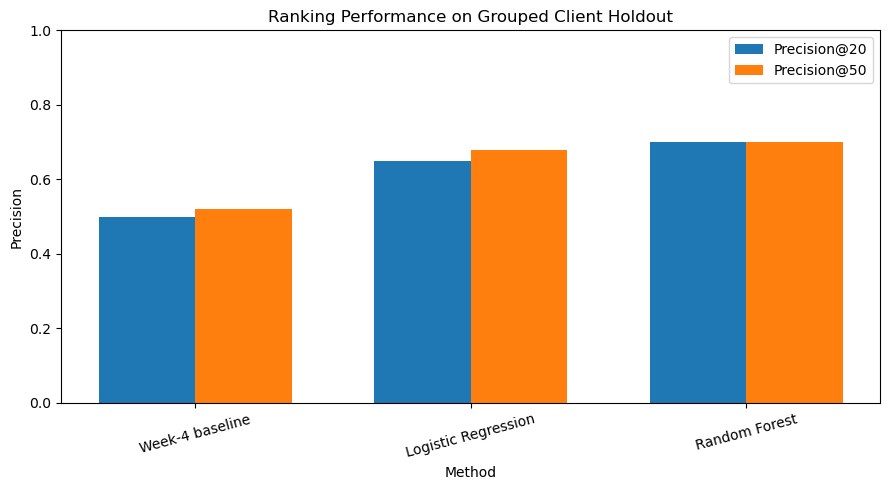

Saved:
- ..\..\work\outputs\capstone_precision_comparison.png


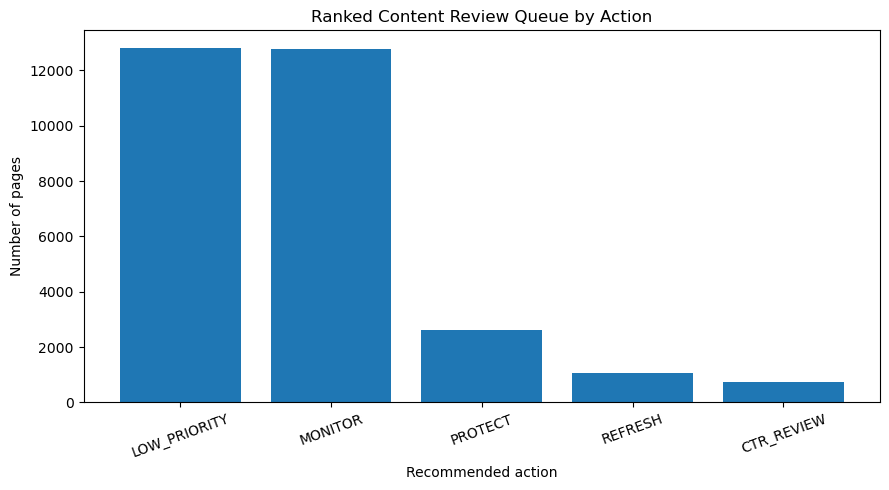

Saved:
- ..\..\work\outputs\capstone_action_distribution.png

Public-paper artifacts created:
1. capstone_model_results.csv
2. capstone_action_counts.csv
3. capstone_precision_comparison.png
4. capstone_action_distribution.png

Public-safety rule:
No client names, domains, URLs, private queries, credentials, or raw page-level recommendation exports are included.

Artifacts section check passed.


In [9]:
from pathlib import Path
import matplotlib.pyplot as plt

# Create output directory
output_dir = Path("../../work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# 1. Save model comparison table
# ---------------------------------------------------------

# Keep only meaningful ranking methods for the public paper.
# The base-rate row is excluded because it does not create
# a meaningful ranked list.

paper_results = results_df[
    results_df["method"].isin([
        "Week-4 baseline",
        "Logistic Regression",
        "Random Forest",
    ])
].copy()

paper_results.to_csv(
    output_dir / "capstone_model_results.csv",
    index=False
)

print("Saved:")
print("-", output_dir / "capstone_model_results.csv")


# ---------------------------------------------------------
# 2. Save action distribution
# ---------------------------------------------------------

action_counts = (
    ranked_queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

action_counts["share"] = (
    action_counts["count"] / len(ranked_queue)
)

action_counts.to_csv(
    output_dir / "capstone_action_counts.csv",
    index=False
)

print("-", output_dir / "capstone_action_counts.csv")


# ---------------------------------------------------------
# 3. Precision comparison chart
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

x = np.arange(len(paper_results))
width = 0.35

plt.bar(
    x - width / 2,
    paper_results["Precision@20"],
    width,
    label="Precision@20"
)

plt.bar(
    x + width / 2,
    paper_results["Precision@50"],
    width,
    label="Precision@50"
)

plt.xticks(
    x,
    paper_results["method"],
    rotation=15
)

plt.ylabel("Precision")
plt.xlabel("Method")
plt.title("Ranking Performance on Grouped Client Holdout")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

precision_chart = (
    output_dir / "capstone_precision_comparison.png"
)

plt.savefig(
    precision_chart,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("-", precision_chart)


# ---------------------------------------------------------
# 4. Action distribution chart
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    action_counts["action"],
    action_counts["count"]
)

plt.xlabel("Recommended action")
plt.ylabel("Number of pages")
plt.title("Ranked Content Review Queue by Action")

plt.xticks(rotation=20)
plt.tight_layout()

action_chart = (
    output_dir / "capstone_action_distribution.png"
)

plt.savefig(
    action_chart,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("-", action_chart)


# ---------------------------------------------------------
# 5. Public-paper summary
# ---------------------------------------------------------

print("\nPublic-paper artifacts created:")
print("1. capstone_model_results.csv")
print("2. capstone_action_counts.csv")
print("3. capstone_precision_comparison.png")
print("4. capstone_action_distribution.png")

print("\nPublic-safety rule:")
print(
    "No client names, domains, URLs, private queries, credentials, "
    "or raw page-level recommendation exports are included."
)


# ---------------------------------------------------------
# Final checks
# ---------------------------------------------------------

assert len(paper_results) == 3
assert action_counts["count"].sum() == len(ranked_queue)
assert precision_chart.exists()
assert action_chart.exists()

print("\nArtifacts section check passed.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
